In [1]:
import os
import glob
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_data(base_path):
    cats_path = os.path.join(base_path, 'cats', '*.jpg')
    humans_path = os.path.join(base_path, 'human', '*.jpg')
    
    cat_files = glob.glob(cats_path)
    human_files = glob.glob(humans_path)
    
    X = []
    y = []
    
    for f in cat_files:
        img = Image.open(f).convert('RGB').resize((64, 64))
        X.append(np.array(img).flatten())
        y.append(0)
            
    for f in human_files:
        img = Image.open(f).convert('RGB').resize((64, 64))
        X.append(np.array(img).flatten())
        y.append(1)
            
    return np.array(X), np.array(y)

X, y_true = load_data('dataset')
print(f"Loaded {len(X)} images. Shape of X: {X.shape}")

Loaded 20 images. Shape of X: (20, 12288)


In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.32613237 0.13618654]


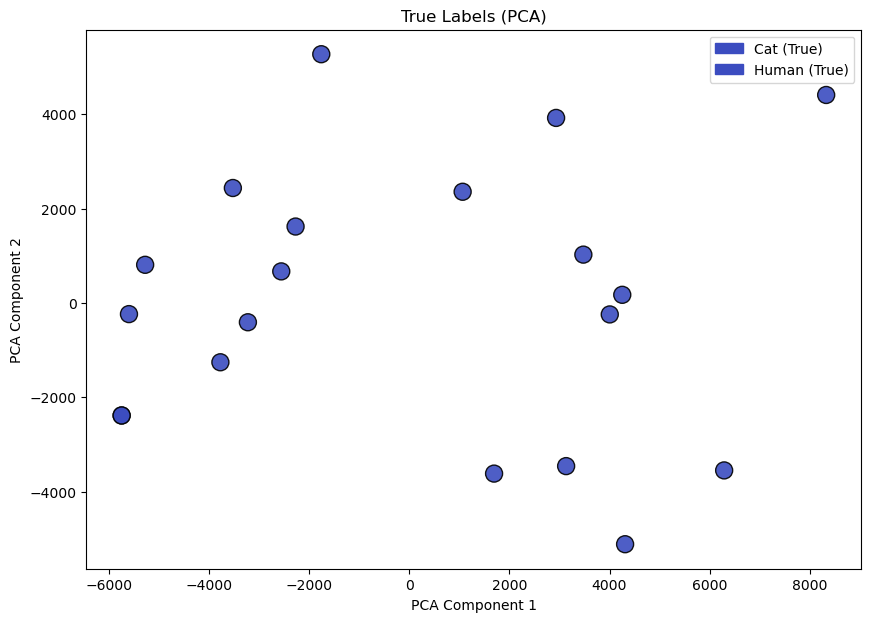

In [4]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', alpha=0.9, s=150, edgecolors='k')
cat_patch = mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Cat (True)')
human_patch = mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Human (True)')
plt.legend(handles=[cat_patch, human_patch])
plt.title('True Labels (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

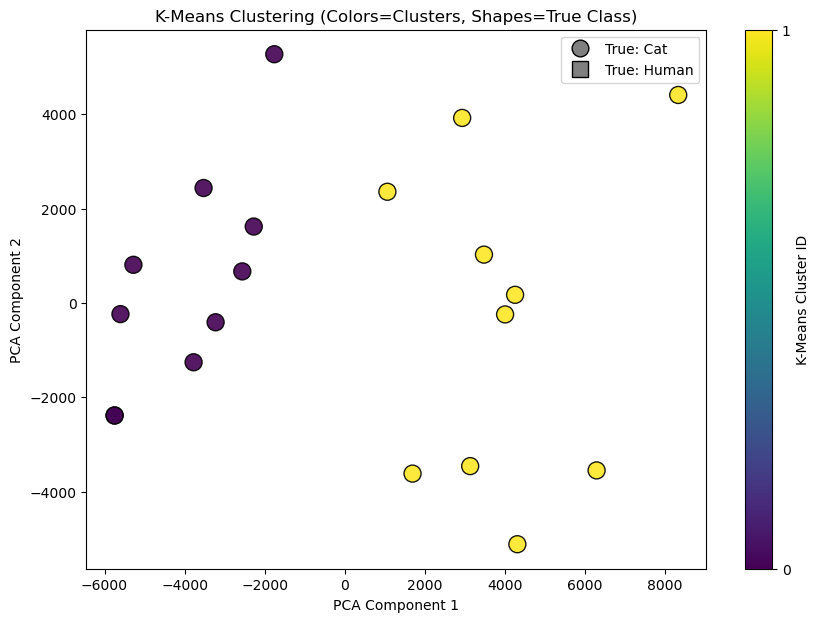

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(10, 7))
for i, marker in zip([0, 1], ['o', 's']): # 0=Cat, 1=Human
    mask = (y_true == i)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=kmeans_labels[mask], cmap='viridis', 
                marker=marker, alpha=0.9, s=150, vmin=0, vmax=1, edgecolors='k')

marker_cat = mlines.Line2D([0], [0], marker='o', color='w', label='True: Cat', markerfacecolor='gray', markersize=12, markeredgecolor='k')
marker_human = mlines.Line2D([0], [0], marker='s', color='w', label='True: Human', markerfacecolor='gray', markersize=12, markeredgecolor='k')
plt.legend(handles=[marker_cat, marker_human], loc='best')

plt.title('K-Means Clustering (Colors=Clusters, Shapes=True Class)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
plt.colorbar(sm, ticks=[0, 1], label='K-Means Cluster ID', ax=plt.gca())
plt.show()

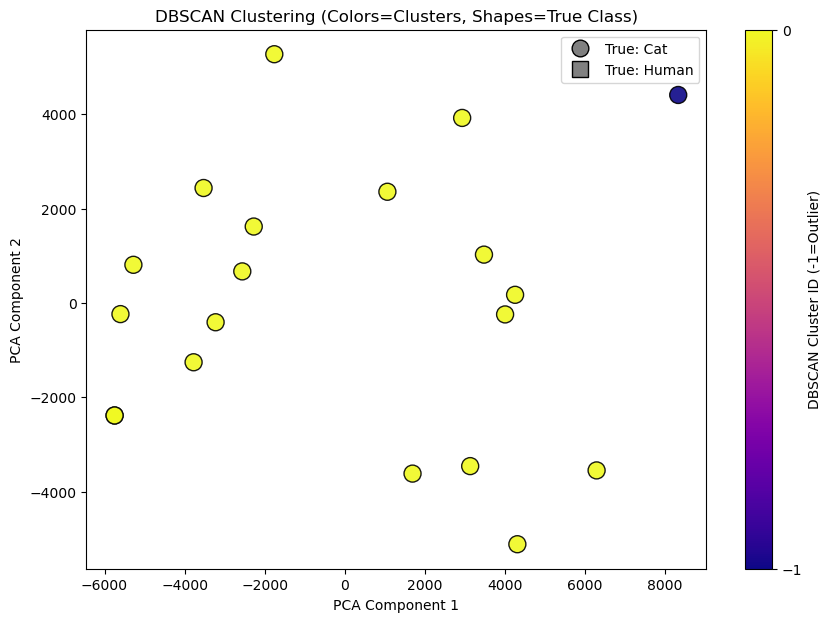

In [6]:
dbscan = DBSCAN(eps=5000, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(10, 7))
vmin, vmax = min(dbscan_labels), max(dbscan_labels)
for i, marker in zip([0, 1], ['o', 's']):
    mask = (y_true == i)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=dbscan_labels[mask], cmap='plasma', 
                marker=marker, alpha=0.9, s=150, vmin=vmin, vmax=vmax, edgecolors='k')

plt.legend(handles=[marker_cat, marker_human], loc='best')
plt.title('DBSCAN Clustering (Colors=Clusters, Shapes=True Class)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
sm_db = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=vmin, vmax=vmax))
plt.colorbar(sm_db, ticks=list(range(vmin, vmax+1)), label='DBSCAN Cluster ID (-1=Outlier)', ax=plt.gca())
plt.show()